# Check and preparation of the bike accident data for training: 

### Check if the data was inserted correctly.

(Afterwards, the data has to be filtered to Delft)

In [45]:
#check size of data set, projection type, column titles
import geopandas as gpd

gdf = gpd.read_file("../data/bron_2022_2024.geojson")
print(gdf.shape)
print(gdf.crs)
print(gdf.columns.tolist())


(382421, 40)
EPSG:28992
['id', 'verkeersongeval_nummer', 'jaar_ongeval', 'verkeersongeval_afloop', 'aantal_partijen', 'partij_1_objecttype', 'partij_1_objecttype_overig', 'partij_2_objecttype', 'partij_2_objecttype_overig', 'aard_ongeval', 'niveau_koppelen', 'wegsituatie', 'bebouwde_kom', 'maximum_snelheid', 'wegverlichting', 'wegverharding', 'wegdek', 'lichtgesteldheid', 'zichtafstand', 'weersgesteldheid', 'bijz_verkeersmaatregel', 'bijz_verkeersmaatregel_overig', 'bijz_infrastructuur', 'bijz_infrastructuur_overig', 'bijz_tijdelijke_aard', 'bijz_tijdelijke_aard_overig', 'junctie_id', 'wegvak_id', 'hectometer', 'straatnaam', 'woonplaats', 'actueel', 'wegbeheerder', 'gemeente', 'provincie', 'dienstnaam', 'districtnaam', 'indicatie_alcohol', 'gdb_geomattr_data', 'geometry']


In [46]:
#check for cyclist columns (= Fiets)
#also integrate E-Bikes later?

print(gdf['partij_1_objecttype'].value_counts())

partij_1_objecttype
Personenauto                           233740
Bestelauto                              26899
Fiets                                   19599
Bromfiets                               18696
Snorfiets                                7328
Motor                                    6727
Trekker                                  3269
Vrachtauto                               2926
Bus                                      1756
e-bike                                   1688
Scootmobiel                               772
Overig wegmeubilair                       550
Brommobiel                                543
Landbouwvoertuig                          495
Lichtmast                                 301
Trein/tram                                208
Trekker met oplegger                      137
Boom                                      134
Voetganger                                112
Onbekend voertuig i.g.v. doorrijder        98
Dier                                       71
Overig vast ob

### Filter data for Delft

To filter out for Delft project the data from EPSG:28992 (meters) to ESPG:4326 (lat/lon degrees) so that it is nicer to check the coordinates for Delft and to keep it consistent throughout the project.

In [47]:
#project data to lat/lon
gdf = gdf.to_crs("EPSG:4326")
print(gdf.crs)  # test if right format (EPSG:4326)

EPSG:4326


Now add coordinates to filter for Delft:

(x-coordinates in [4.30,4.40] and y-coordinates in [51.95,52.05] in lat/lon)

In [48]:
delft = gdf[
    (gdf.geometry.x >= 4.30) & (gdf.geometry.x <= 4.40) &
    (gdf.geometry.y >= 51.95) & (gdf.geometry.y <= 52.05) 
]
print(f"accidents that happened in Delft: {len(delft)}")

accidents that happened in Delft: 6025


In [57]:
cyclists = delft[
    (delft['partij_1_objecttype'] == 'Fiets') |
    (delft['partij_2_objecttype'] == 'Fiets') |
    (delft['partij_1_objecttype'] == 'e-bike')| #also consider e-bikes 
    (delft['partij_2_objecttype'] == 'e-bike')
]
print(f"cyclist accidents in Delft: {len(cyclists)}") 

cyclist accidents in Delft: 1215


Select the accidents involved with bikes (Fiets, including e-bikes)

This results in 1116 total bike accidents, 6025 including e-bikes in Delft

In [50]:
#save the filtered data in GeoJSON file to train on 
cyclists.to_file("../data/bron_delft_cyclists.geojson", driver="GeoJSON")

### Sanity Check

Plot all 1116 points (only fiets) or 1215 points (including e-bikes) to see if filtered out correclty

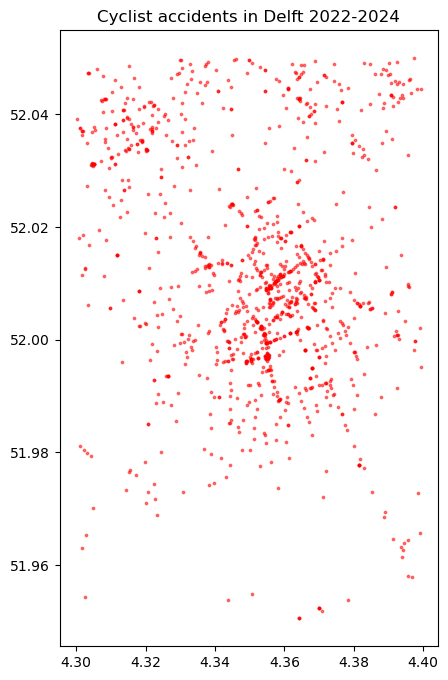

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
cyclists.plot(ax=ax, markersize=3, color='red', alpha=0.5)
ax.set_title("Cyclist accidents in Delft 2022-2024")
plt.show()

The above plot shows a map of all bike accidents in Delft. 

One can clearly see the main roads (lines of points) and structure of the city (cluster of points in the center) which is what is expected.

This implies data is real and loaded correctly. 

# Download and preparation of the OSM road network data

Download entire road network for Delft directly from the OpenStreetMap

In [2]:
import osmnx as ox

G = ox.graph_from_place(
    ["Delft, Netherlands", "Rijswijk, Netherlands", "Pijnacker-Nootdorp, Netherlands", "Midden-Delfland, Netherlands", "Den Haag, Netherlands", "Westland, Netherlands",],
    network_type="bike"
)

#maybe could change it to bounding box later for more exact data: but will take hours to load all the data
#G = ox.graph_from_bbox(bbox=(51.95, 52.05, 4.30, 4.40), network_type="bike")

#G = ox.graph_from_place('Zuid-Holland, Netherlands', network_type='bike')


print(f"Nodes: {len(G.nodes)}, Edges: {len(G.edges)}")

Nodes: 49078, Edges: 116625


The graph G is not usable as a table and needs to be converted to edges i.e. road segments.

In [53]:
#edges = GeoDataFrame of road segments (one segment per row)

nodes, road_segments = ox.graph_to_gdfs(G)
road_segments.to_file("../data/osm_road_segments.geojson", driver="GeoJSON")
print(road_segments.shape)
print(road_segments.crs)
print(road_segments.columns.tolist())

(116625, 17)
epsg:4326
['osmid', 'bridge', 'highway', 'name', 'oneway', 'reversed', 'length', 'geometry', 'width', 'lanes', 'maxspeed', 'service', 'access', 'tunnel', 'ref', 'junction', 'est_width']


There are 5712 road segments in Delft, 116625 road segments when including outskirts and the data is already in EPSG:4326 (lat/lon) so no need to convert.

For the columns, I will focus on:
- highway (road type)
- maxspeed
- lanes (num of lanes)
- junction (roundabouts or other)
- geometry (LineString, actual shape of the road segment as a line on the map)

The points of the accidents might not lie directly on the road but a little bit distanced. To mitigate this issue I'll use a 20m wide corridor later to also count accident points that are slightly off the road.

### Sanity check

First plot the road network and then overlay it with the accident points to check if the dots lay on lines i.e. accidents happen on the roads.

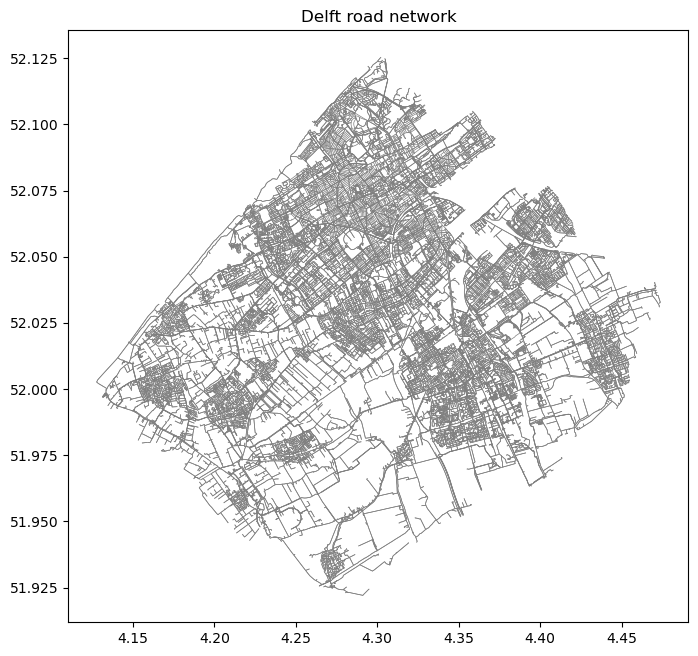

In [54]:
#plot road network
fig, ax = plt.subplots(figsize=(8, 8))
road_segments.plot(ax=ax, linewidth=0.5, color="grey")
ax.set_title("Delft road network")
plt.show()

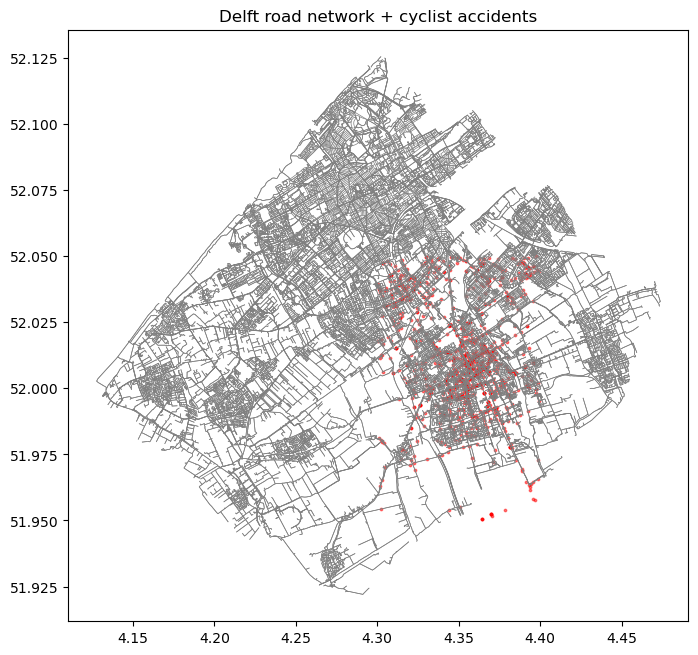

In [55]:
#plot road network with accidents
fig, ax = plt.subplots(figsize=(8, 8))
road_segments.plot(ax=ax, linewidth=0.5, color="grey")
cyclists.plot(ax=ax, markersize=3, color="red", alpha=0.5)
ax.set_title("Delft road network + cyclist accidents")
plt.show()

The road networks don't cover all points, ca. 10 points in the southern area fall outside and will be dropped. 

This is fine as there are still enough points on the net. 

The bounding box approach (commented above) could be used to fix this, but the request is too large and would be split into 9575 separate queries. Therefore, it would take hours to load all the data.

In [56]:
#Print for sanity check

#both should have the format EPSG:4326 
print(cyclists.crs)
print(road_segments.crs)

#should be 1116 bike accidents
print(len(cyclists))

#number of road segments (is a lot because of Den Haag network included, but necessary to cover all points)
#most of the roads will have 0 accidents
print(len(road_segments))

EPSG:4326
epsg:4326
1215
116625


# NDW Fietsdata for Delft

In [6]:
import pandas as pd

#load both files
ndw_raw = pd.concat([
    pd.read_csv("../data/fiets-data-ndw-dexter1.csv"),
    pd.read_csv("../data/fiets-data-ndw-dexter2.csv")
], ignore_index=True)

#check
print(f"total rows: {len(ndw_raw)}")
print(f"unique locations: {ndw_raw['locatiecode'].nunique()}")
print(f"date range: {ndw_raw['begintijd'].min()} to {ndw_raw['begintijd'].max()}")

total rows: 4527
unique locations: 14
date range: 2024-01-01 00:00:00 to 2024-12-13 00:00:00


I checked out the NDW bike count data for 35 locations in Delft from 2024 (earlier years have even less data points available on the website), but most of them were incomplete. Only 14 locations provided usable data, which is too sparse to be a useful model feature.

14 measurement points spread across 116,625 segments means the majority of segments will get the median fallback value, which means the model will effectively only see real cyclist counts for a tiny fraction of roads.

Therefore I decided not to use this additional data for training. Counts of cyclists on the streets of Delft would be the most useful next feature, but I have not found enough data to actually integrate it. 
